### Advanced Agentic rag
- we can apply best pracitics to improve the autonomous agentic rag.

In [2]:
### document inject phase
## load a datasource and split it
## store the data in the vector

from langchain_core.documents.base import Document
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter



# this method will give retriver for a .txt file 
def create_retriver(filename):
    loader = TextLoader("rag_data/"+filename, encoding="utf-8")
    documents = loader.load()
    print(f" Loaded {len(documents)} file")
    ### Recursive text splitter
    recursive_chr_splitter = RecursiveCharacterTextSplitter(
        separators = ["\n\n", "\n", " ", ""],
        chunk_size = 100,
        chunk_overlap = 20, 
    )
    chunk_docs = recursive_chr_splitter.split_documents(documents)

    ## Save the chunk list into the vector stroe (chroma)
    from langchain_chroma import Chroma
    from langchain_huggingface import HuggingFaceEmbeddings

    embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

    # store in Chroma
    vector_store = Chroma.from_documents(
        documents=chunk_docs,
        embedding=embedding_model,
        collection_name="leav_doc",
    )

    #result = vector_store.similarity_search("Casual Leaves per year", 2)
    return vector_store.as_retriever();


## we have this two retriver
leave_policy_retriver = create_retriver("leave_policy.txt")
work_timing_policy_retriver = create_retriver("work_timing_policy.txt")


 Loaded 1 file
 Loaded 1 file


### Tool creation

In [3]:
from langchain_core.tools import Tool

def search_in_leave_poicey(query: str):
    return leave_policy_retriver.invoke(query)

def search_in_work_timing(query: str):
    return work_timing_policy_retriver.invoke(query)

leave_policy_retriever_tool = Tool(
    name="leave_policy_search",
    description="search the leave policey related queries.",
    func=search_in_leave_poicey
)

work_timing_policy_retriver_tool = Tool(
    name="search_in_work_timing_search",
    description="search the work time policy related queries.",
    func=search_in_work_timing
)

tools=[leave_policy_retriever_tool, work_timing_policy_retriver_tool]


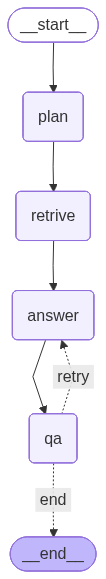

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


state of plan::: {'question': 'leave policey', 'feedback': 'notthing for now', 'retry_count': 0, 'is_answer_good': True, 'messages': [HumanMessage(content='leave policey', additional_kwargs={}, response_metadata={}, id='4cf3bc0a-8b28-42fa-90e6-8c6c771e129f')]}
Sub questions are
Understand the context, identify key regulations, propose next steps.
generate_answer pahse
{'question': 'leave policey', 'sub_qus': ['Understand the context', 'identify key regulations', 'propose next steps.'], 'retrived_docs': [Document(id='8218cd55-8ec9-49b4-bda4-6cf542f0b1c5', metadata={'source': 'rag_data/leave_policy.txt'}, page_content='6. Emergency Situations\n-----------------------'), Document(id='6e418104-b7d9-4023-8b99-8f7f627559c8', metadata={'source': 'rag_data/work_timing_policy.txt'}, page_content='3. Breaks\n---------'), Document(id='cb8faa5c-3021-4a76-9123-057493b37d9c', metadata={'source': 'rag_data/leave_policy.txt'}, page_content='9. Non-Compliance\n-----------------'), Document(id='b1bf04cb

In [4]:

from decimal import Context
from typing import Annotated, List
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.agents import create_agent
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from IPython.display import Image,display
from langgraph.constants import START, END
from pprint import pprint

# loads environment variables from .env
load_dotenv()  
llm = ChatGroq(model_name="openai/gpt-oss-20b", api_key=os.getenv("GROQ_API_KEY"))


# state creation 
class State(TypedDict):
    question: str
    sub_qus: List[str]
    retrived_docs: List[Document]
    feedback: str
    retry_count : int
    is_answer_good : bool
    answer: str
    messages: Annotated[list, add_messages]

# agent creation/ just shortcut of manually creating toolnode and edges
agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="you are AI agent for  company ZEN X, use your tools to answer company level private data"
)

# Query decomposition/planing phase
def plan_step(state: State)-> State:
    print(f"state of plan::: {state}")
    prompt = f"Break the question into 2-3 reasoning steps (comma separated):\n\n{state['question']}"
    result = llm.invoke(prompt).content
    print("Sub questions are")
    print(result)
    subqs= [line.strip("- ") for line in result.split(",") if line.strip()]
    #state["sub_qus"] = subqs
    return {**state, "sub_qus": subqs}

# based on sub question fetch doc for each documents
def retrive_doc(state: State)-> State:
    all_docs = []
    for sub in state["sub_qus"]:
        docs = leave_policy_retriver.invoke(sub)
        all_docs.extend(docs)

    state["retrived_docs"] = all_docs
    #return state
    return {**state, "retrived_docs": all_docs}

def generate_answer(state: State)-> State:
    context = "\n\n".join([doc.page_content for doc in state["retrived_docs"]])
    print("generate_answer pahse")
    print(state)
    prompt = f"""
            you are answering a complex question using reasoning and retrived documents
            attemet: {state["retry_count"]}
            QA feedback: {state["feedback"]}
            question: {state["question"]}
            releavent informations: {context}
            now synthesize a well reasoned final answer.
        """
    answer = llm.invoke(prompt).content
    return {
        **state,
        "answer": answer,
        "messages": state["messages"] + [{"role": "assistant", "content": answer}]
    }

def self_reflection(state: State)-> State:
    prompt = f""" 
        verify the following answe to see if it fully addresses the question.
        State YES if is complete and correct, or No with an explantion.

        Question: {state["question"]}
        Answer: {state["answer"]}

        Respond like:
            satisfied answer: Yes/No
            explanation: ....
    """
    result = llm.invoke(prompt).content
    print(f"qa response: {result}")
    is_ok = "satisfied answer: yes" in result.lower()
    print(f"qa isOkay: {is_ok}")
    if not is_ok:
       retry_count = state["retry_count"] + 1
    else:
        retry_count = state["retry_count"]

    return {
        **state,
        "is_answer_good": is_ok,
        "feedback": result,
        "retry_count": retry_count
    }

def check_answer(state: State):
    if state["is_answer_good"]:
        return "end"
    else:
        return "retry"

graph_builder = StateGraph(State)

graph_builder.add_node("plan", plan_step)
graph_builder.add_node("retrive", retrive_doc)
graph_builder.add_node("answer", generate_answer)
graph_builder.add_node("qa", self_reflection)

graph_builder.add_edge(START, "plan")
graph_builder.add_edge("plan", "retrive")
graph_builder.add_edge("retrive", "answer")
graph_builder.add_edge("answer", "qa")
graph_builder.add_conditional_edges("qa", check_answer,{
        "retry": "answer",
        "end": END
})
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

### using in another file
agentic_app = graph

# CLI CHATBOT
while True:
    input_msg = input("You: ")
    if input_msg in {"quit", "exit"}:
        break
    response = graph.invoke({
        "messages": [{"role": "user", "content": input_msg}],
        "question": input_msg,
        "retry_count": 0,
        "feedback": "notthing for now",
        "is_answer_good": True
    })
    pprint(response)

